In [ ]:
#Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

#Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier  # Example classifier

In [ ]:
# Load dataset
fetaldata = pd.read_csv("fetal_health.csv")

In [ ]:
# Quick look
print(fetaldata.head())
print(fetaldata.info())
print(fetaldata['fetal_health'].value_counts())  # Check class distribution

   baseline value  accelerations  fetal_movement  uterine_contractions  \
0           120.0          0.000             0.0                 0.000   
1           132.0          0.006             0.0                 0.006   
2           133.0          0.003             0.0                 0.008   
3           134.0          0.003             0.0                 0.008   
4           132.0          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.000                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                             73.0

In [ ]:
#X is all the features & Y is the label. The label is what you are TRYING to classify, and X is all the features used in order to classify that.
#Basically, X is everything except for Y.

X = fetaldata.drop(columns=['fetal_health'])
y = fetaldata['fetal_health']

In [ ]:
print(X.head)

<bound method NDFrame.head of       baseline value  accelerations  fetal_movement  uterine_contractions  \
0              120.0          0.000           0.000                 0.000   
1              132.0          0.006           0.000                 0.006   
2              133.0          0.003           0.000                 0.008   
3              134.0          0.003           0.000                 0.008   
4              132.0          0.007           0.000                 0.008   
...              ...            ...             ...                   ...   
2121           140.0          0.000           0.000                 0.007   
2122           140.0          0.001           0.000                 0.007   
2123           140.0          0.001           0.000                 0.007   
2124           140.0          0.001           0.000                 0.006   
2125           142.0          0.002           0.002                 0.008   

      light_decelerations  severe_deceleratio

In [ ]:
#Splitting into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestClassifier(random_state=42)

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9460093896713615


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.89      0.77      0.82        64
         3.0       0.90      0.93      0.92        29

    accuracy                           0.95       426
   macro avg       0.92      0.89      0.90       426
weighted avg       0.94      0.95      0.94       426



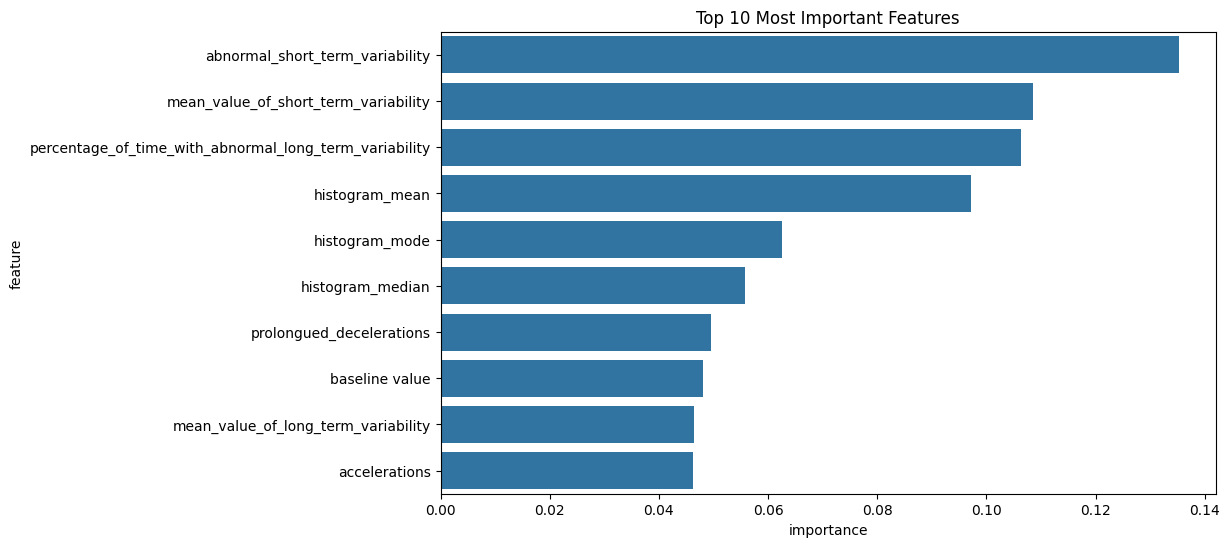

In [ ]:
import seaborn as sns
# Get feature importance
importances = model.feature_importances_
features = X.columns

# Create a DataFrame for easier plotting
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10))
plt.title("Top 10 Most Important Features")
plt.show()

In [ ]:
import numpy as np

# Create a new CTG record as a list or array
new_record = np.array([[132, 0.005, 0, 0.006, 0.003, 0, 0, 16, 2.1, 0, 0.3, 65, 140, 4, 1, 120, 137, 136, 137, 12, 1]])

# Make prediction
prediction = model.predict(new_record)

print("Predicted fetal health class:", prediction[0])

Predicted fetal health class: 1.0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
prediction_proba = model.predict_proba(new_record)
print("Prediction probabilities for each class:", prediction_proba)

Prediction probabilities for each class: [[0.89 0.09 0.02]]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
